# Web Scraping — Goodreads

**Notebook:** `webscraping-goodreads-notebook.ipynb`

## Objetivo

O objetivo deste notebook é coletar informações da lista **Best Books Ever**, do Goodreads, e organizar os resultados em uma base estruturada para análise descritiva e uso posterior na construção de um dashboard em html.

A estrutura segue o fluxo utilizado no notebook de referência da disciplina:

1. acessar uma página do site;
2. inspecionar o HTML;
3. localizar o padrão dos registros;
4. testar a extração em uma página;
5. automatizar a coleta em várias páginas;
6. transformar os dados em um `DataFrame`;
7. realizar análises descritivas;
8. salvar as bases finais.

Neste projeto, a análise de gêneros não será utilizada. Os testes com páginas individuais dos livros não retornaram esse campo de forma consistente, então ele foi retirado para evitar informações incorretas.

## 1. Bibliotecas utilizadas

As principais bibliotecas são:

- **`requests`**: realiza as requisições HTTP;
- **`BeautifulSoup`**: interpreta o HTML e permite localizar os elementos desejados;
- **`pandas`**: organiza e trata os dados;
- **`matplotlib`**: produz os gráficos;
- **`pathlib`**: organiza os caminhos dos arquivos;
- **`re`**: auxilia na extração de números e identificadores a partir de textos.

In [1]:
import random
import re
import time
from pathlib import Path
from urllib.parse import urljoin

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup

## 2. Configuração do projeto

O notebook foi preparado para ser salvo dentro da pasta `codigos` do repositório.

A estrutura utilizada é:

```text
webscraping-goodreads/
├── README.md
├── dados/
├── codigos/
│   └── webscraping-goodreads-notebook.ipynb
└── dashboard/
```

Os arquivos gerados durante o scraping e as bases finais são salvos automaticamente na pasta `dados`.

In [2]:
BASE_URL = "https://www.goodreads.com"
URL_LISTA = "https://www.goodreads.com/list/show/1.Best_Books_Ever?page={pagina}"

# Estrutura esperada do repositório:
# webscraping-goodreads/
# ├── codigos/
# │   └── webscraping-goodreads-notebook.ipynb
# ├── dados/
# └── dashboard/
#
# O código abaixo funciona tanto quando o notebook é executado a partir
# da pasta "codigos" quanto quando o VS Code utiliza a raiz do repositório
# como diretório de trabalho.

PASTA_ATUAL = Path.cwd()

if PASTA_ATUAL.name.lower() == "codigos":
    PASTA_REPOSITORIO = PASTA_ATUAL.parent
elif (PASTA_ATUAL / "dados").exists():
    PASTA_REPOSITORIO = PASTA_ATUAL
elif (PASTA_ATUAL.parent / "dados").exists():
    PASTA_REPOSITORIO = PASTA_ATUAL.parent
else:
    raise FileNotFoundError(
        "Não foi possível localizar a pasta 'dados'. "
        "Execute o notebook dentro do repositório webscraping-goodreads."
    )

PASTA_DADOS = PASTA_REPOSITORIO / "dados"
PASTA_DADOS.mkdir(parents=True, exist_ok=True)

ARQUIVO_PARCIAL = PASTA_DADOS / "goodreads_lista_parcial.csv"
ARQUIVO_FINAL = PASTA_DADOS / "goodreads_best_books.csv"
ARQUIVO_DASHBOARD = PASTA_DADOS / "goodreads_dashboard.csv"

PAGINA_INICIAL = 1
PAGINA_FINAL = 25

TIMEOUT = 30
TENTATIVAS = 3
PAUSA_MIN = 1.5
PAUSA_MAX = 3.0

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
}

session = requests.Session()
session.headers.update(headers)

print("Repositório:", PASTA_REPOSITORIO)
print("Pasta de dados:", PASTA_DADOS)

Repositório: c:\Users\bella\webscraping-goodreads
Pasta de dados: c:\Users\bella\webscraping-goodreads\dados


## 3. Capturando o HTML de uma página

Antes de automatizar a coleta, fazemos uma requisição simples para verificar se a página está acessível.

O código de resposta **200** indica que a requisição foi bem-sucedida.

In [3]:
url_teste = URL_LISTA.format(pagina=1)

response = session.get(
    url_teste,
    timeout=TIMEOUT
)

print("Status:", response.status_code)
print("URL:", response.url)

Status: 200
URL: https://www.goodreads.com/list/show/1.Best_Books_Ever?page=1


In [4]:
soup = BeautifulSoup(
    response.text,
    "html.parser"
)

print(
    soup.get_text(
        separator=" ",
        strip=True
    )[:1500]
)

Best Books Ever (79414 books) Home My Books Browse ▾ Recommendations Choice Awards Genres Giveaways New Releases Lists Explore News & Interviews Genres Art Biography Business Children's Christian Classics Comics Cookbooks Ebooks Fantasy Fiction Graphic Novels Historical Fiction History Horror Memoir Music Mystery Nonfiction Poetry Psychology Romance Science Science Fiction Self Help Sports Thriller Travel Young Adult More Genres Community ▾ Groups Quotes Ask the Author Sign In Join Sign up View profile Profile Friends Groups Discussions Comments Reading Challenge Kindle Notes & Highlights Quotes Favorite genres Friends’ recommendations Account settings Help Sign out Home My Books Browse ▾ Recommendations Choice Awards Genres Giveaways New Releases Lists Explore News & Interviews Genres Art Biography Business Children's Christian Classics Comics Cookbooks Ebooks Fantasy Fiction Graphic Novels Historical Fiction History Horror Memoir Music Mystery Nonfiction Poetry Psychology Romance Sci

## 4. Localizando o padrão dos livros

Na lista do Goodreads, cada livro aparece em uma linha da tabela identificada por:

```html
<tr itemtype="http://schema.org/Book">
```

Dentro desse bloco podem ser localizados, entre outros elementos:

- posição no ranking;
- título;
- autor;
- link do livro;
- link do autor;
- capa;
- avaliação média;
- quantidade de avaliações;
- score da lista;
- quantidade de votos recebidos na lista.

Esse padrão permite selecionar todos os livros da página com o seletor CSS utilizado abaixo.

In [5]:
livros_teste = soup.select(
    '#all_votes tr[itemtype="http://schema.org/Book"]'
)

print(
    "Livros encontrados na página de teste:",
    len(livros_teste)
)

Livros encontrados na página de teste: 100


## 5. Funções auxiliares

As funções abaixo são usadas para limpar textos, transformar URLs relativas em absolutas e extrair identificadores numéricos.

In [6]:
def texto(elemento):
    if elemento is None:
        return None
    return elemento.get_text(" ", strip=True)


def normalizar_url(url):
    if not url:
        return None
    return urljoin(BASE_URL, str(url))


def extrair_id_book(url):
    if not url:
        return None

    match = re.search(
        r"/book/show/(\d+)",
        str(url)
    )

    return int(match.group(1)) if match else None


def extrair_id_autor(url):
    if not url:
        return None

    match = re.search(
        r"/author/show/(\d+)",
        str(url)
    )

    return int(match.group(1)) if match else None


def extrair_inteiro(valor):
    if valor is None:
        return None

    match = re.search(
        r"[\d,\.]+",
        str(valor)
    )

    if not match:
        return None

    numero = (
        match.group()
        .replace(",", "")
        .replace(".", "")
    )

    try:
        return int(numero)
    except ValueError:
        return None

## 6. Extraindo as informações de um livro

Primeiro definimos uma função responsável por receber o bloco HTML correspondente a um livro e devolver um dicionário com as informações extraídas.

In [7]:
def extrair_livro_lista(livro):
    ranking = extrair_inteiro(
        texto(
            livro.select_one("td.number")
        )
    )

    titulo_elemento = livro.select_one(
        "a.bookTitle"
    )

    titulo = texto(
        titulo_elemento
    )

    url_livro = (
        normalizar_url(
            titulo_elemento.get("href")
        )
        if titulo_elemento
        else None
    )

    book_id = extrair_id_book(
        url_livro
    )

    autor_elemento = livro.select_one(
        "a.authorName"
    )

    autor = texto(
        autor_elemento
    )

    url_autor = (
        normalizar_url(
            autor_elemento.get("href")
        )
        if autor_elemento
        else None
    )

    author_id = extrair_id_autor(
        url_autor
    )

    capa_elemento = livro.select_one(
        "img.bookCover"
    )

    url_capa = (
        capa_elemento.get("src")
        if capa_elemento
        else None
    )

    minirating = texto(
        livro.select_one(
            "span.minirating"
        )
    )

    avaliacao_media = None
    numero_avaliacoes = None

    if minirating:
        match_rating = re.search(
            r"([0-9]+\.[0-9]+)\s+avg rating",
            minirating
        )

        if match_rating:
            avaliacao_media = float(
                match_rating.group(1)
            )

        match_numero = re.search(
            r"([\d,]+)\s+ratings",
            minirating
        )

        if match_numero:
            numero_avaliacoes = int(
                match_numero.group(1)
                .replace(",", "")
            )

    texto_completo = texto(
        livro
    )

    score = None
    numero_votos_lista = None

    if texto_completo:
        match_score = re.search(
            r"score:\s*([\d,]+)",
            texto_completo,
            flags=re.IGNORECASE
        )

        if match_score:
            score = int(
                match_score.group(1)
                .replace(",", "")
            )

        match_votos = re.search(
            r"([\d,]+)\s+people voted",
            texto_completo,
            flags=re.IGNORECASE
        )

        if match_votos:
            numero_votos_lista = int(
                match_votos.group(1)
                .replace(",", "")
            )

    return {
        "ranking": ranking,
        "book_id": book_id,
        "titulo": titulo,
        "autor": autor,
        "author_id": author_id,
        "url_livro": url_livro,
        "url_autor": url_autor,
        "url_capa": url_capa,
        "avaliacao_media": avaliacao_media,
        "numero_avaliacoes": numero_avaliacoes,
        "score": score,
        "numero_votos_lista": numero_votos_lista
    }

## 7. Testando a extração

Antes de percorrer todas as páginas, testamos a função no primeiro livro encontrado.

In [8]:
if livros_teste:
    exemplo_livro = extrair_livro_lista(
        livros_teste[0]
    )

    exemplo_livro
else:
    print(
        "Nenhum livro foi encontrado na página de teste."
    )

## 8. Função para baixar uma página

Como requisições podem falhar por instabilidade de conexão ou resposta do servidor, a função abaixo realiza até três tentativas antes de registrar a página como erro.

In [9]:
def baixar_pagina_lista(pagina):
    url = URL_LISTA.format(
        pagina=pagina
    )

    for tentativa in range(
        1,
        TENTATIVAS + 1
    ):
        try:
            response = session.get(
                url,
                timeout=TIMEOUT
            )

            response.raise_for_status()

            return response

        except requests.RequestException as erro:
            print(
                f"Página {pagina} - "
                f"tentativa {tentativa}: {erro}"
            )

            if tentativa < TENTATIVAS:
                time.sleep(
                    random.uniform(
                        3,
                        6
                    )
                )

    return None

## 9. Coleta das páginas da lista

A lista possui 100 livros por página. Neste notebook serão percorridas as páginas 1 a 25, totalizando até aproximadamente 2.500 posições.

Entre as requisições é feita uma pequena pausa para evitar acessos sucessivos em alta frequência. A cada página processada também é salvo um arquivo parcial, permitindo recuperar o trabalho caso a execução seja interrompida.

In [10]:
dados_lista = []
paginas_com_erro = []

for pagina in range(
    PAGINA_INICIAL,
    PAGINA_FINAL + 1
):
    print(
        f"Processando página "
        f"{pagina}/{PAGINA_FINAL}"
    )

    response = baixar_pagina_lista(
        pagina
    )

    if response is None:
        paginas_com_erro.append(
            pagina
        )
        continue

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    livros = soup.select(
        '#all_votes tr[itemtype="http://schema.org/Book"]'
    )

    print(
        "Livros encontrados:",
        len(livros)
    )

    for livro in livros:
        registro = extrair_livro_lista(
            livro
        )

        registro["pagina_lista"] = pagina

        dados_lista.append(
            registro
        )

    pd.DataFrame(
        dados_lista
    ).to_csv(
        ARQUIVO_PARCIAL,
        index=False,
        encoding="utf-8-sig"
    )

    if pagina < PAGINA_FINAL:
        time.sleep(
            random.uniform(
                PAUSA_MIN,
                PAUSA_MAX
            )
        )

print(
    "Total de registros coletados:",
    len(dados_lista)
)

print(
    "Páginas com erro:",
    paginas_com_erro
)

Processando página 1/25
Livros encontrados: 100
Processando página 2/25
Livros encontrados: 100
Processando página 3/25
Livros encontrados: 100
Processando página 4/25
Livros encontrados: 100
Processando página 5/25
Livros encontrados: 100
Processando página 6/25
Livros encontrados: 100
Processando página 7/25
Livros encontrados: 100
Processando página 8/25
Livros encontrados: 100
Processando página 9/25
Livros encontrados: 100
Processando página 10/25
Livros encontrados: 100
Processando página 11/25
Livros encontrados: 100
Processando página 12/25
Livros encontrados: 100
Processando página 13/25
Livros encontrados: 100
Processando página 14/25
Livros encontrados: 100
Processando página 15/25
Livros encontrados: 100
Processando página 16/25
Livros encontrados: 100
Processando página 17/25
Livros encontrados: 100
Processando página 18/25
Livros encontrados: 100
Processando página 19/25
Livros encontrados: 100
Processando página 20/25
Livros encontrados: 100
Processando página 21/25
Livr

# Organização da base

## 10. Criando o DataFrame

Os registros coletados são transformados em um `DataFrame`. Em seguida, duplicatas de livros são removidas pelo identificador `book_id`, e a base é ordenada pelo ranking.

In [11]:
df = pd.DataFrame(
    dados_lista
)

if "book_id" in df.columns:
    df = df.drop_duplicates(
        subset="book_id"
    )

if "ranking" in df.columns:
    df = df.sort_values(
        "ranking"
    )

df = df.reset_index(
    drop=True
)

print(
    f"Linhas: {len(df):,}"
)

print(
    f"Colunas: {len(df.columns)}"
)

df.head(10)

Linhas: 2,500
Colunas: 13


,ranking,book_id,titulo,autor,author_id,url_livro,url_autor,url_capa,avaliacao_media,numero_avaliacoes,score,numero_votos_lista,pagina_lista
0,1,2767052,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,153394,https://www.goodreads.com/book/show/2767052-th...,https://www.goodreads.com/author/show/153394.S...,https://i.gr-assets.com/images/S/compressed.ph...,4.36,10270211,4535327,46087,1
1,2,1885,Pride and Prejudice,Jane Austen,1265,https://www.goodreads.com/book/show/1885.Pride...,https://www.goodreads.com/author/show/1265.Jan...,https://i.gr-assets.com/images/S/compressed.ph...,4.30,5004751,3078758,31536,1
2,3,2657,To Kill a Mockingbird,Harper Lee,1825,https://www.goodreads.com/book/show/2657.To_Ki...,https://www.goodreads.com/author/show/1825.Har...,https://i.gr-assets.com/images/S/compressed.ph...,4.26,7117291,2671346,27274,1
3,4,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling,1077326,https://www.goodreads.com/book/show/2.Harry_Po...,https://www.goodreads.com/author/show/1077326....,https://i.gr-assets.com/images/S/compressed.ph...,4.50,3920125,2120502,21733,1
4,5,19063,The Book Thief,Markus Zusak,11466,https://www.goodreads.com/book/show/19063.The_...,https://www.goodreads.com/author/show/11466.Ma...,https://i.gr-assets.com/images/S/compressed.ph...,4.39,2976551,2025572,20800,1
5,6,41865,"Twilight (The Twilight Saga, #1)",Stephenie Meyer,941441,https://www.goodreads.com/book/show/41865.Twil...,https://www.goodreads.com/author/show/941441.S...,https://i.gr-assets.com/images/S/compressed.ph...,3.68,7506815,1801448,18365,1
6,7,170448,Animal Farm,George Orwell,3706,https://www.goodreads.com/book/show/170448.Ani...,https://www.goodreads.com/author/show/3706.Geo...,https://i.gr-assets.com/images/S/compressed.ph...,4.03,4802644,1785398,18470,1
7,8,30,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,J.R.R. Tolkien,656983,https://www.goodreads.com/book/show/30.J_R_R_T...,https://www.goodreads.com/author/show/656983.J...,https://i.gr-assets.com/images/S/compressed.ph...,4.62,147332,1720719,17813,1
8,9,11127,The Chronicles of Narnia (The Chronicles of Na...,C.S. Lewis,1069006,https://www.goodreads.com/book/show/11127.The_...,https://www.goodreads.com/author/show/1069006....,https://i.gr-assets.com/images/S/compressed.ph...,4.28,722660,1564911,16298,1
9,10,11870085,The Fault in Our Stars,John Green,1406384,https://www.goodreads.com/book/show/11870085-t...,https://www.goodreads.com/author/show/1406384....,https://i.gr-assets.com/images/S/compressed.ph...,4.12,5879511,1451669,15020,1


## 11. Verificação dos tipos e valores ausentes

Esta etapa permite conferir se as variáveis foram carregadas corretamente e identificar possíveis campos sem informação.

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ranking             2500 non-null   int64  
 1   book_id             2500 non-null   int64  
 2   titulo              2500 non-null   str    
 3   autor               2500 non-null   str    
 4   author_id           2500 non-null   int64  
 5   url_livro           2500 non-null   str    
 6   url_autor           2500 non-null   str    
 7   url_capa            2500 non-null   str    
 8   avaliacao_media     2500 non-null   float64
 9   numero_avaliacoes   2500 non-null   int64  
 10  score               2500 non-null   int64  
 11  numero_votos_lista  2500 non-null   int64  
 12  pagina_lista        2500 non-null   int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 254.0 KB


In [13]:
df.isna().sum().sort_values(
    ascending=False
)

ranking               0
book_id               0
titulo                0
autor                 0
author_id             0
url_livro             0
url_autor             0
url_capa              0
avaliacao_media       0
numero_avaliacoes     0
score                 0
numero_votos_lista    0
pagina_lista          0
dtype: int64

## 12. Ajuste dos tipos numéricos

In [14]:
colunas_numericas = [
    "ranking",
    "book_id",
    "author_id",
    "avaliacao_media",
    "numero_avaliacoes",
    "score",
    "numero_votos_lista",
    "pagina_lista"
]

for coluna in colunas_numericas:
    if coluna in df.columns:
        df[coluna] = pd.to_numeric(
            df[coluna],
            errors="coerce"
        )

# Análise descritiva

As análises abaixo utilizam apenas variáveis com interpretação direta para o objetivo do projeto. Identificadores técnicos, URLs e o indicador de *Goodreads Author* não são usados como variáveis analíticas.

## 13. Resumo das principais variáveis numéricas

In [15]:
variaveis_descritivas = [
    "ranking",
    "avaliacao_media",
    "numero_avaliacoes",
    "score",
    "numero_votos_lista"
]

df[
    variaveis_descritivas
].describe().T

,count,mean,std,min,25%,50%,75%,max
ranking,2500.0,1250.407600,721.747749,1.00,625.75,1250.5,1875.25,2500.00
avaliacao_media,2500.0,4.092104,0.243128,3.01,3.94,4.1,4.27,4.82
numero_avaliacoes,2500.0,407969.349200,821381.539956,106.00,49894.50,149463.0,391080.75,11799675.00
score,2500.0,55952.332800,208298.608905,3313.00,4705.00,7583.5,21114.75,4535327.00
numero_votos_lista,2500.0,620.407600,2168.773863,34.00,56.00,96.0,274.00,46087.00


## 14. Nota ponderada dos livros

Usar apenas a avaliação média pode favorecer livros com poucas avaliações. Para equilibrar a nota e a quantidade de avaliações, será utilizada uma média ponderada pela popularidade.

A fórmula utilizada é:

\[
WR = \frac{v}{v+m}R + \frac{m}{v+m}C
\]

em que:

- \(R\) é a avaliação média do livro;
- \(v\) é o número de avaliações do livro;
- \(C\) é a avaliação média geral da base;
- \(m\) é o percentil 75 da quantidade de avaliações.

Assim, livros com muitas avaliações têm maior peso de sua própria nota, enquanto livros menos avaliados ficam mais próximos da média geral.

In [16]:
C = df[
    "avaliacao_media"
].mean()

m = df[
    "numero_avaliacoes"
].quantile(
    0.75
)

df["nota_ponderada"] = (
    (
        df["numero_avaliacoes"]
        / (
            df["numero_avaliacoes"]
            + m
        )
    )
    * df["avaliacao_media"]
    +
    (
        m
        / (
            df["numero_avaliacoes"]
            + m
        )
    )
    * C
)

print(
    f"Avaliação média geral: {C:.3f}"
)

print(
    f"Percentil 75 do número de avaliações: {m:,.0f}"
)

Avaliação média geral: 4.092
Percentil 75 do número de avaliações: 391,081


## 15. Top 10 autores com mais livros na lista

In [17]:
top_autores = (
    df.groupby(
        "autor",
        as_index=False
    )
    .agg(
        quantidade_livros=(
            "book_id",
            "count"
        ),
        avaliacao_media=(
            "avaliacao_media",
            "mean"
        ),
        total_avaliacoes=(
            "numero_avaliacoes",
            "sum"
        )
    )
    .sort_values(
        [
            "quantidade_livros",
            "total_avaliacoes"
        ],
        ascending=[
            False,
            False
        ]
    )
    .head(10)
)

top_autores

,autor,quantidade_livros,avaliacao_media,total_avaliacoes
1327,Stephen King,30,4.080333,13437619
1272,Sarah J. Maas,26,4.375000,56498582
1193,Rick Riordan,19,4.336842,13674836
1485,William Shakespeare,16,3.929375,7956173
565,J.K. Rowling,15,4.308667,59781057
1061,Nicholas Sparks,13,4.085385,6112346
216,Cassandra Clare,12,4.303333,8358372
198,C.S. Lewis,12,4.140000,7963259
1192,Richelle Mead,12,4.282500,2987544
570,J.R.R. Tolkien,11,4.418182,16974777


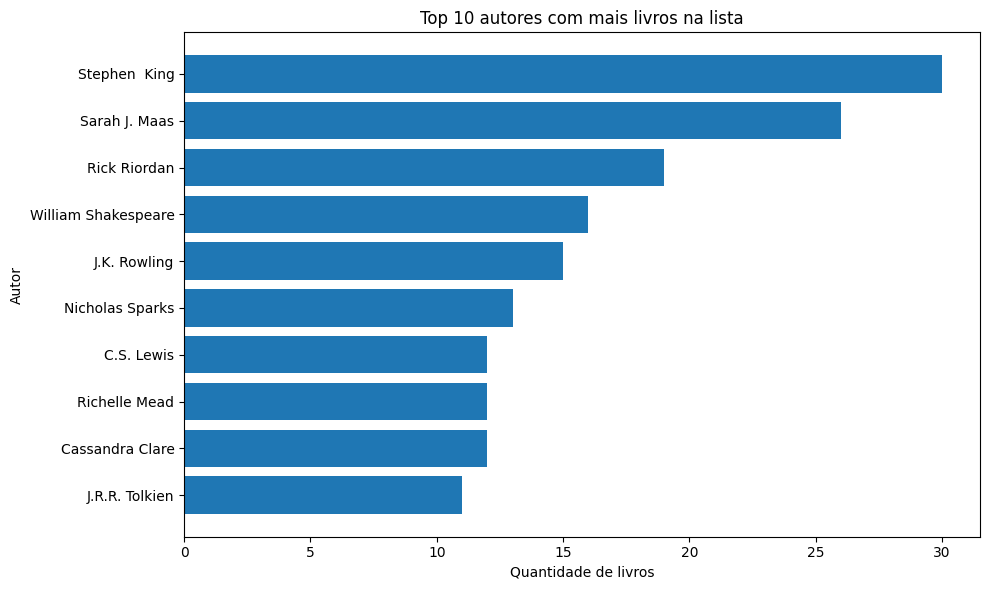

In [18]:
dados_grafico = top_autores.sort_values(
    "quantidade_livros"
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    dados_grafico["autor"],
    dados_grafico["quantidade_livros"]
)

plt.xlabel(
    "Quantidade de livros"
)
plt.ylabel(
    "Autor"
)
plt.title(
    "Top 10 autores com mais livros na lista"
)

plt.tight_layout()
plt.show()

## 16. Top 5 livros pela nota ponderada

In [19]:
top_5_ponderado = (
    df[
        [
            "ranking",
            "titulo",
            "autor",
            "avaliacao_media",
            "numero_avaliacoes",
            "nota_ponderada"
        ]
    ]
    .dropna()
    .sort_values(
        "nota_ponderada",
        ascending=False
    )
    .head(5)
)

top_5_ponderado

,ranking,titulo,autor,avaliacao_media,numero_avaliacoes,nota_ponderada
421,422,A Court of Mist and Fury (A Court of Thorns an...,Sarah J. Maas,4.63,3473428,4.575566
192,193,A Court of Mist and Fury (A Court of Thorns an...,Sarah J. Maas,4.63,3473428,4.575566
48,49,Harry Potter and the Deathly Hallows (Harry Po...,J.K. Rowling,4.62,4229086,4.575315
496,497,The Nightingale,Kristin Hannah,4.65,2374955,4.571121
881,882,"Kingdom of Ash (Throne of Glass, #7)",Sarah J. Maas,4.71,1248342,4.562602


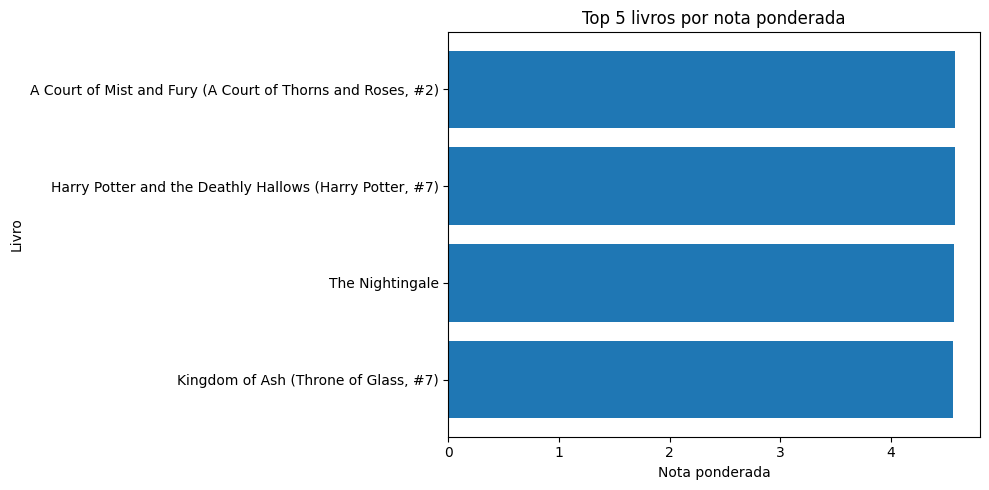

In [20]:
dados_grafico = top_5_ponderado.sort_values(
    "nota_ponderada"
)

plt.figure(
    figsize=(10, 5)
)

plt.barh(
    dados_grafico["titulo"],
    dados_grafico["nota_ponderada"]
)

plt.xlabel(
    "Nota ponderada"
)
plt.ylabel(
    "Livro"
)
plt.title(
    "Top 5 livros por nota ponderada"
)

plt.tight_layout()
plt.show()

## 17. Top 10 livros com maior número de avaliações

O número de avaliações funciona como uma medida de popularidade dentro da plataforma.

In [21]:
top_avaliados = (
    df[
        [
            "ranking",
            "titulo",
            "autor",
            "avaliacao_media",
            "numero_avaliacoes"
        ]
    ]
    .dropna(
        subset=["numero_avaliacoes"]
    )
    .sort_values(
        "numero_avaliacoes",
        ascending=False
    )
    .head(10)
)

top_avaliados

,ranking,titulo,autor,avaliacao_media,numero_avaliacoes
111,112,Harry Potter and the Sorcerer's Stone (Harry P...,J.K. Rowling,4.47,11799675
69,70,Harry Potter and the Philosopher's Stone (Harr...,J.K. Rowling,4.47,11799675
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4.36,10270211
5,6,"Twilight (The Twilight Saga, #1)",Stephenie Meyer,3.68,7506815
2,3,To Kill a Mockingbird,Harper Lee,4.26,7117291
87,88,To Kill a Mockingbird,Harper Lee,4.26,7117291
19,20,The Great Gatsby,F. Scott Fitzgerald,3.93,6137332
9,10,The Fault in Our Stars,John Green,4.12,5879511
130,131,1984,George Orwell,4.21,5756673
32,33,1984,George Orwell,4.21,5756673


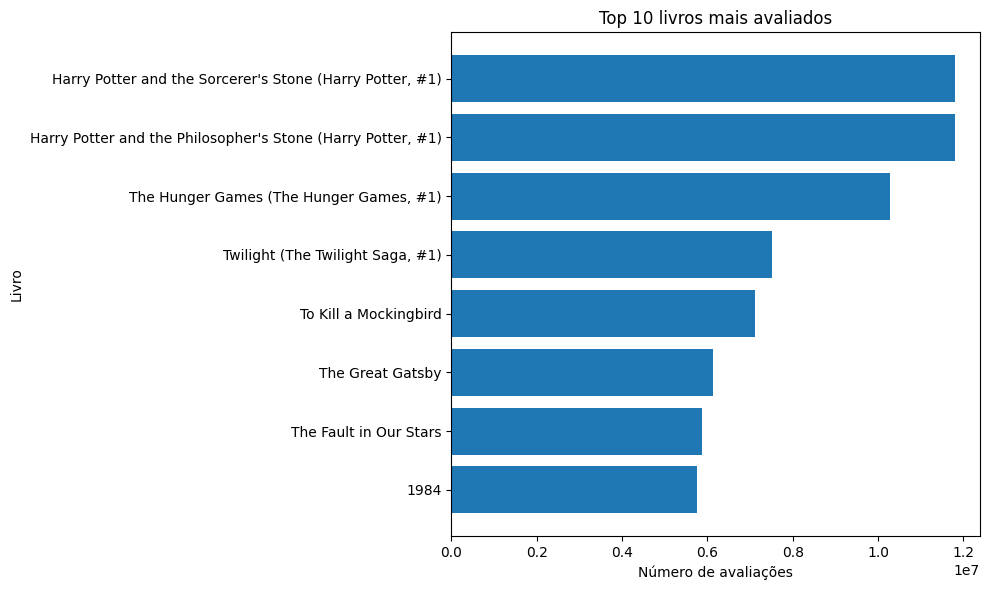

In [22]:
dados_grafico = top_avaliados.sort_values(
    "numero_avaliacoes"
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    dados_grafico["titulo"],
    dados_grafico["numero_avaliacoes"]
)

plt.xlabel(
    "Número de avaliações"
)
plt.ylabel(
    "Livro"
)
plt.title(
    "Top 10 livros mais avaliados"
)

plt.tight_layout()
plt.show()

## 18. Distribuição das avaliações médias

O histograma mostra como as notas médias dos livros da lista estão distribuídas.

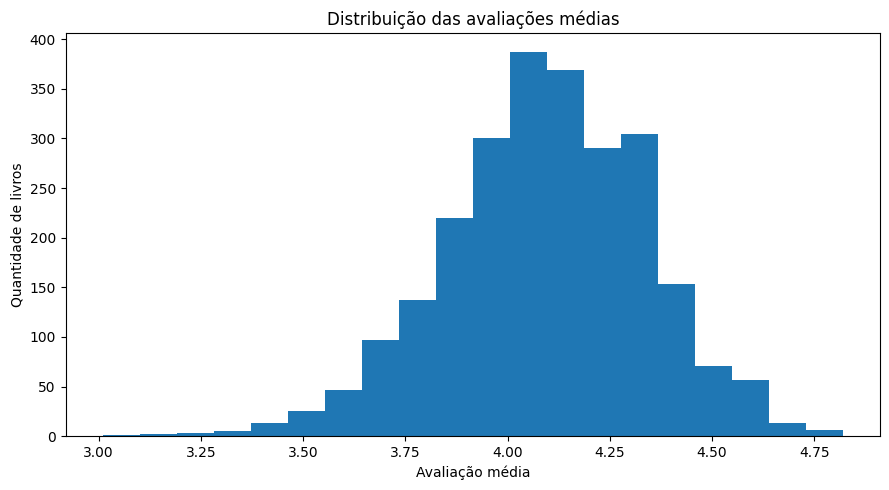

In [23]:
plt.figure(
    figsize=(9, 5)
)

plt.hist(
    df[
        "avaliacao_media"
    ].dropna(),
    bins=20
)

plt.xlabel(
    "Avaliação média"
)
plt.ylabel(
    "Quantidade de livros"
)
plt.title(
    "Distribuição das avaliações médias"
)

plt.tight_layout()
plt.show()

## 19. Distribuição da popularidade

Como o número de avaliações apresenta valores muito diferentes entre os livros, é utilizada a transformação `log10(n + 1)` apenas para facilitar a visualização da distribuição.

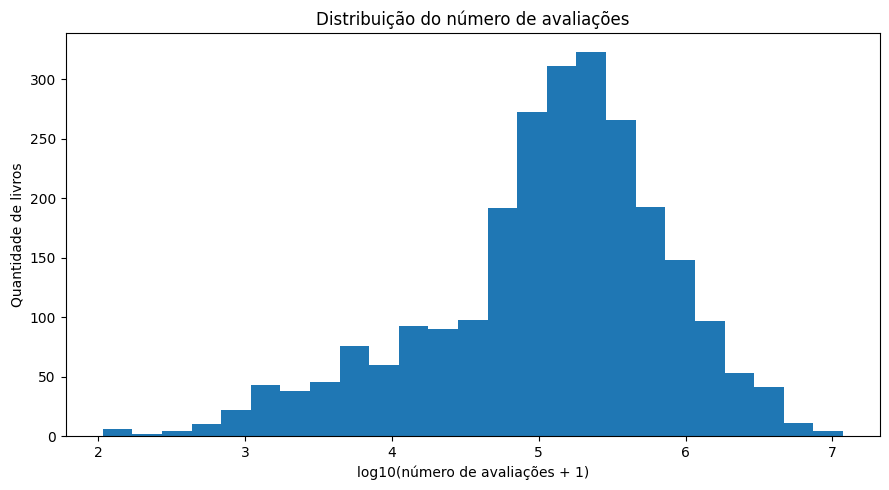

In [24]:
plt.figure(
    figsize=(9, 5)
)

plt.hist(
    np.log10(
        df[
            "numero_avaliacoes"
        ].dropna()
        + 1
    ),
    bins=25
)

plt.xlabel(
    "log10(número de avaliações + 1)"
)
plt.ylabel(
    "Quantidade de livros"
)
plt.title(
    "Distribuição do número de avaliações"
)

plt.tight_layout()
plt.show()

## 20. Relação entre avaliação média e popularidade

O gráfico permite observar se livros com maior número de avaliações também apresentam avaliações médias mais altas. O eixo horizontal está em escala logarítmica para acomodar a grande diferença de popularidade entre os títulos.

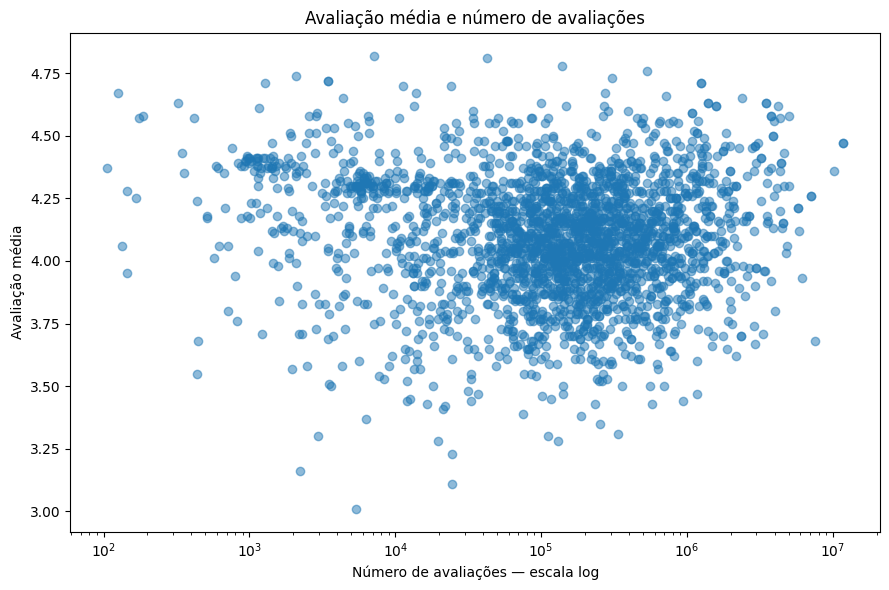

In [25]:
dados_scatter = df[
    [
        "avaliacao_media",
        "numero_avaliacoes"
    ]
].dropna()

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    dados_scatter[
        "numero_avaliacoes"
    ],
    dados_scatter[
        "avaliacao_media"
    ],
    alpha=0.5
)

plt.xscale(
    "log"
)

plt.xlabel(
    "Número de avaliações — escala log"
)
plt.ylabel(
    "Avaliação média"
)
plt.title(
    "Avaliação média e número de avaliações"
)

plt.tight_layout()
plt.show()

## 21. Top 10 livros por score da lista

O `score` é uma medida própria da lista do Goodreads e está relacionado aos votos recebidos pelos livros. Por isso, ele é apresentado como ranking descritivo, sem tratá-lo como uma avaliação independente dos usuários.

In [26]:
top_score = (
    df[
        [
            "ranking",
            "titulo",
            "autor",
            "score",
            "numero_votos_lista",
            "avaliacao_media"
        ]
    ]
    .dropna(
        subset=["score"]
    )
    .sort_values(
        "score",
        ascending=False
    )
    .head(10)
)

top_score

,ranking,titulo,autor,score,numero_votos_lista,avaliacao_media
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4535327,46087,4.36
1,2,Pride and Prejudice,Jane Austen,3078758,31536,4.30
2,3,To Kill a Mockingbird,Harper Lee,2671346,27274,4.26
3,4,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling,2120502,21733,4.50
4,5,The Book Thief,Markus Zusak,2025572,20800,4.39
5,6,"Twilight (The Twilight Saga, #1)",Stephenie Meyer,1801448,18365,3.68
6,7,Animal Farm,George Orwell,1785398,18470,4.03
7,8,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,J.R.R. Tolkien,1720719,17813,4.62
8,9,The Chronicles of Narnia (The Chronicles of Na...,C.S. Lewis,1564911,16298,4.28
9,10,The Fault in Our Stars,John Green,1451669,15020,4.12


# Preparação para o dashboard

## 22. Faixas de avaliação e popularidade

As faixas abaixo serão utilizadas como filtros no dashboard. Elas não substituem as variáveis numéricas originais.

In [27]:
df["faixa_avaliacao"] = pd.cut(
    df["avaliacao_media"],
    bins=[
        0,
        3.5,
        4.0,
        4.25,
        4.5,
        5.0
    ],
    labels=[
        "Até 3,5",
        "3,5 a 4,0",
        "4,0 a 4,25",
        "4,25 a 4,5",
        "Acima de 4,5"
    ],
    include_lowest=True
)

df["faixa_popularidade"] = pd.qcut(
    df["numero_avaliacoes"],
    q=4,
    labels=[
        "Baixa",
        "Média",
        "Alta",
        "Muito alta"
    ],
    duplicates="drop"
)

## 23. Indicadores gerais

In [28]:
indicadores = pd.Series({
    "total_livros": len(df),
    "autores_unicos": df[
        "autor"
    ].nunique(),
    "avaliacao_media_geral": df[
        "avaliacao_media"
    ].mean(),
    "mediana_avaliacao": df[
        "avaliacao_media"
    ].median(),
    "total_avaliacoes": df[
        "numero_avaliacoes"
    ].sum(),
    "mediana_numero_avaliacoes": df[
        "numero_avaliacoes"
    ].median(),
    "total_votos_lista": df[
        "numero_votos_lista"
    ].sum()
})

indicadores

total_livros                 2.500000e+03
autores_unicos               1.502000e+03
avaliacao_media_geral        4.092104e+00
mediana_avaliacao            4.100000e+00
total_avaliacoes             1.019923e+09
mediana_numero_avaliacoes    1.494630e+05
total_votos_lista            1.551019e+06
dtype: float64

## 24. Base simplificada para o dashboard

A base do dashboard mantém apenas as colunas necessárias para visualizações, filtros e tabelas.

In [29]:
colunas_dashboard = [
    "ranking",
    "book_id",
    "titulo",
    "autor",
    "url_livro",
    "url_capa",
    "avaliacao_media",
    "numero_avaliacoes",
    "nota_ponderada",
    "score",
    "numero_votos_lista",
    "faixa_avaliacao",
    "faixa_popularidade"
]

df_dashboard = df[
    [
        coluna
        for coluna in colunas_dashboard
        if coluna in df.columns
    ]
].copy()

df_dashboard.head()

,ranking,book_id,titulo,autor,url_livro,url_capa,avaliacao_media,numero_avaliacoes,nota_ponderada,score,numero_votos_lista,faixa_avaliacao,faixa_popularidade
0,1,2767052,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,https://www.goodreads.com/book/show/2767052-th...,https://i.gr-assets.com/images/S/compressed.ph...,4.36,10270211,4.350173,4535327,46087,"4,25 a 4,5",Muito alta
1,2,1885,Pride and Prejudice,Jane Austen,https://www.goodreads.com/book/show/1885.Pride...,https://i.gr-assets.com/images/S/compressed.ph...,4.30,5004751,4.284932,3078758,31536,"4,25 a 4,5",Muito alta
2,3,2657,To Kill a Mockingbird,Harper Lee,https://www.goodreads.com/book/show/2657.To_Ki...,https://i.gr-assets.com/images/S/compressed.ph...,4.26,7117291,4.251255,2671346,27274,"4,25 a 4,5",Muito alta
3,4,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling,https://www.goodreads.com/book/show/2.Harry_Po...,https://i.gr-assets.com/images/S/compressed.ph...,4.50,3920125,4.462999,2120502,21733,"4,25 a 4,5",Muito alta
4,5,19063,The Book Thief,Markus Zusak,https://www.goodreads.com/book/show/19063.The_...,https://i.gr-assets.com/images/S/compressed.ph...,4.39,2976551,4.355406,2025572,20800,"4,25 a 4,5",Muito alta


# Exportação

## 25. Salvando as bases finais

As bases são salvas automaticamente na pasta `dados` do repositório:

```text
webscraping-goodreads/
└── dados/
    ├── goodreads_lista_parcial.csv
    ├── goodreads_best_books.csv
    └── goodreads_dashboard.csv
```

- `goodreads_lista_parcial.csv`: arquivo atualizado durante a coleta, usado como segurança em caso de interrupção;
- `goodreads_best_books.csv`: base completa obtida e tratada no notebook;
- `goodreads_dashboard.csv`: base simplificada preparada para a construção do dashboard.

In [30]:
df.to_csv(
    ARQUIVO_FINAL,
    index=False,
    encoding="utf-8-sig"
)

df_dashboard.to_csv(
    ARQUIVO_DASHBOARD,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Base completa salva em:"
)

print(
    ARQUIVO_FINAL
)

print()

print(
    "Base para o dashboard salva em:"
)

print(
    ARQUIVO_DASHBOARD
)

Base completa salva em:
c:\Users\bella\webscraping-goodreads\dados\goodreads_best_books.csv

Base para o dashboard salva em:
c:\Users\bella\webscraping-goodreads\dados\goodreads_dashboard.csv


# Observações finais

A coleta deste notebook utiliza somente as páginas da lista **Best Books Ever**, pois elas forneceram de forma consistente as informações necessárias para o projeto.

A tentativa de obter gênero por meio das páginas individuais dos livros foi retirada da versão final porque esse conteúdo não foi recuperado de forma estável. Manter apenas campos coletados de maneira consistente reduz o risco de construir análises a partir de categorias incorretas.